In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Configuration
LOG_DIR = "../models/rl_filter_v3"  # Adjust if your logs are elsewhere

In [2]:
def load_logs(log_dir):
    all_records = []
    # Look for analysis_logs_cycle_*.jsonl
    log_files = sorted(glob.glob(os.path.join(log_dir, "analysis_logs_cycle_*.jsonl")))
    
    if not log_files:
        print(f"No log files found in {log_dir}")
        return pd.DataFrame()
        
    print(f"Found {len(log_files)} log files.")
    
    for file_path in log_files:
        try:
            cycle_num = int(file_path.split('_cycle_')[-1].split('.')[0])
        except ValueError:
            cycle_num = 0
            
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    episode = json.loads(line)
                except json.JSONDecodeError:
                    continue
                
                # Extract episode-level metrics
                ep_id = episode.get('episode_id')
                final_reward = episode.get('final_reward')
                success = episode.get('success')
                
                # Extract recall events
                for recall in episode.get('recall_events', []):
                    obs_text = recall.get('observation_text', '')
                    goal_text = recall.get('goal_text', '')
                    
                    for cand in recall.get('candidates', []):
                        record = {
                            'cycle': cycle_num,
                            'episode_id': ep_id,
                            'final_reward': final_reward,
                            'success': success,
                            'observation_text': obs_text,
                            'goal_text': goal_text,
                            'memory_id': cand.get('memory_id'),
                            'similarity_score': cand.get('similarity_score'),
                            'gate_score': cand.get('gate_score'),
                            'gate_action': cand.get('gate_action'), # 1=Keep, 0=Discard
                            'selected': cand.get('selected'),
                            'memory_content': cand.get('memory_content')
                        }
                        all_records.append(record)
                        
    return pd.DataFrame(all_records)

df = load_logs(LOG_DIR)
if not df.empty:
    print(f"Loaded {len(df)} memory candidate evaluations.")
    display(df.head())
else:
    print("DataFrame is empty. Please run training to generate logs.")

Found 30 log files.
Loaded 2157 memory candidate evaluations.


,cycle,episode_id,final_reward,success,observation_text,goal_text,memory_id,similarity_score,gate_score,gate_action,selected,memory_content
0,1,127788936801280,1.483333,True,**Page Overview** \n- **Site:** GitLab instan...,Tell me the full names of the repositories whe...,567a6047-59a8-4777-9574-ba40bc35f64b,0.942724,NaN,None,True,{'obs_summary': '**Page:** GitLab – Dashboard ...
1,1,127788936801280,1.483333,True,**Page Overview** \n- **Site:** GitLab instan...,Tell me the full names of the repositories whe...,be137ffc-d974-4033-8354-960a45ec6900,0.934730,NaN,None,True,{'obs_summary': '**Page Overview** - **URL**...
2,1,127788936801280,1.483333,True,**Page Overview** \n- **Site:** GitLab instan...,Tell me the full names of the repositories whe...,e17d782f-dd09-4760-8a9d-5f391b2dae47,0.883756,NaN,None,True,"{'obs_summary': '', 'action_taken': 'Attempt t..."
3,1,127788936801280,1.483333,True,**Page Overview** \n- **Title / Context:** Gi...,Tell me the full names of the repositories whe...,567a6047-59a8-4777-9574-ba40bc35f64b,0.930716,NaN,None,True,{'obs_summary': '**Page:** GitLab – Dashboard ...
4,1,127788936801280,1.483333,True,**Page Overview** \n- **Title / Context:** Gi...,Tell me the full names of the repositories whe...,be137ffc-d974-4033-8354-960a45ec6900,0.921624,NaN,None,True,{'obs_summary': '**Page Overview** - **URL**...


## 1. Gate Score Distribution
This histogram shows the distribution of gate scores (0.0 to 1.0) across different training cycles. 
- **Early cycles**: Should be around 0.5 (random initialization).
- **Later cycles**: Should polarize towards 0 (discard) or 1 (keep) as the agent becomes more confident.

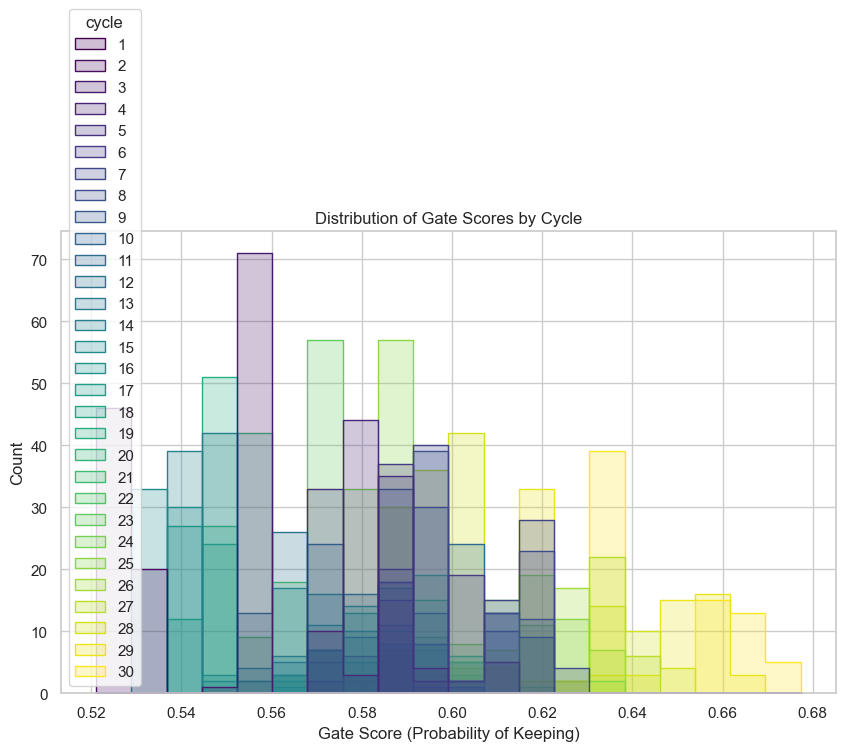

In [3]:
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='gate_score', hue='cycle', element="step", bins=20, palette="viridis")
    plt.title("Distribution of Gate Scores by Cycle")
    plt.xlabel("Gate Score (Probability of Keeping)")
    plt.ylabel("Count")
    plt.show()

## 2. Similarity vs. Gate Score
Does the filter just learn to mimic the similarity score? 
- If points lie on the diagonal, the filter is redundant (Gate ≈ Similarity).
- If points are scattered, the filter is learning a distinct signal (e.g., rejecting high-similarity but irrelevant memories).

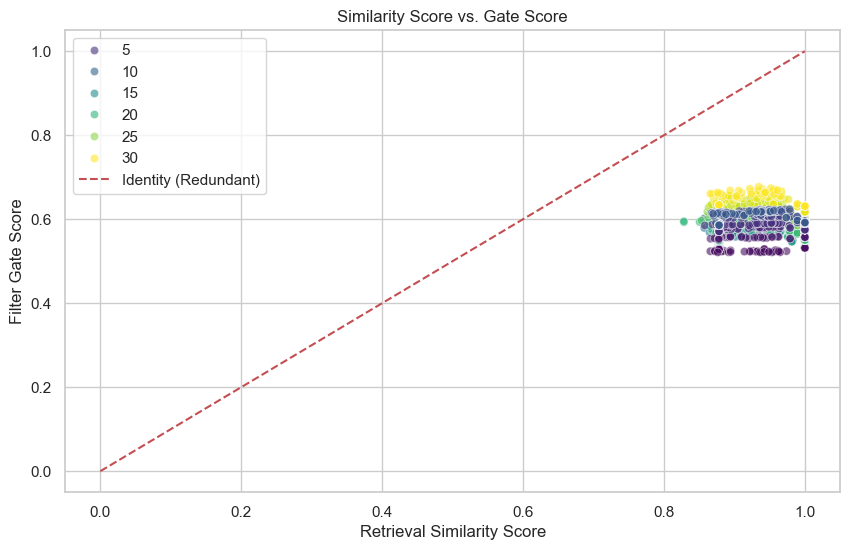

In [4]:
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='similarity_score', y='gate_score', hue='cycle', palette="viridis", alpha=0.6)
    plt.title("Similarity Score vs. Gate Score")
    plt.xlabel("Retrieval Similarity Score")
    plt.ylabel("Filter Gate Score")
    plt.plot([0, 1], [0, 1], 'r--', label="Identity (Redundant)")
    plt.legend()
    plt.show()

## 3. Qualitative Analysis
Let's look at specific examples where the filter made a strong decision.
- **Kept (High Score)**: What does the agent think is useful?
- **Discarded (Low Score)**: What does the agent think is noise?

In [5]:
def print_example(row):
    print("="*80)
    print(f"Cycle: {row['cycle']} | Gate Score: {row['gate_score']:.4f} | Action: {'KEEP' if row['gate_action'] else 'DISCARD'}")
    print(f"Similarity: {row['similarity_score']:.4f}")
    print("-"*80)
    print(f"GOAL: {row['goal_text']}")
    print("-"*80)
    print(f"OBSERVATION (Snippet): {row['observation_text'][:200]}...")
    print("-"*80)
    print(f"MEMORY CONTENT:\n{row['memory_content']}")
    print("="*80 + "\n")

if not df.empty:
    print("### EXAMPLES OF HIGH CONFIDENCE 'KEEP' ###")
    high_conf_keep = df[df['gate_score'] > 0.8].sample(min(3, len(df[df['gate_score'] > 0.8])))
    for _, row in high_conf_keep.iterrows():
        print_example(row)

    print("\n### EXAMPLES OF HIGH CONFIDENCE 'DISCARD' ###")
    high_conf_discard = df[df['gate_score'] < 0.2].sample(min(3, len(df[df['gate_score'] < 0.2])))
    for _, row in high_conf_discard.iterrows():
        print_example(row)

### EXAMPLES OF HIGH CONFIDENCE 'KEEP' ###

### EXAMPLES OF HIGH CONFIDENCE 'DISCARD' ###


## 4. Success Rate Correlation
Do episodes with higher average gate scores tend to succeed more?

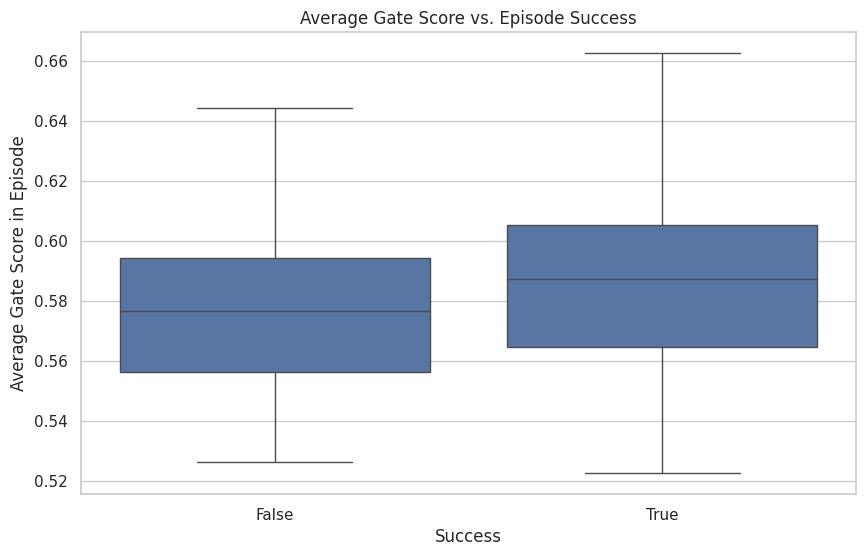

In [6]:
if not df.empty:
    # Group by episode
    episode_stats = df.groupby('episode_id').agg({
        'gate_score': 'mean',
        'success': 'first',
        'final_reward': 'first',
        'cycle': 'first'
    }).reset_index()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=episode_stats, x='success', y='gate_score')
    plt.title("Average Gate Score vs. Episode Success")
    plt.xlabel("Success")
    plt.ylabel("Average Gate Score in Episode")
    plt.show()